<a href="https://colab.research.google.com/github/zubaeteee20210205109-droid/Trial/blob/main/RCNN_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import torch
import torchvision
import matplotlib.patches as patches
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torch.utils.data import DataLoader
from PIL import Image
import torchvision.transforms as T
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [3]:
class SkinDataset(torch.utils.data.Dataset):
    def __init__(self, root, transforms=None):
        self.root = Path(root)
        self.transforms = transforms

        # Recursively get all images
        self.imgs = list(self.root.rglob("*.*"))
        self.imgs = [img for img in self.imgs if img.suffix.lower() in [".png", ".jpg", ".jpeg"]]

        # Labels based on parent folder name
        self.labels = []
        for img in self.imgs:
            if "not_infected" in img.parent.name.lower() or "healthy" in img.parent.name.lower():
                self.labels.append(1)  # Healthy / Not Infected
            else:
                self.labels.append(2)  # Affected / Infected

    def __getitem__(self, idx):
        img_path = self.imgs[idx]
        img = Image.open(img_path).convert("RGB")

        w, h = img.size
        boxes = torch.tensor([[0, 0, w, h]], dtype=torch.float32)
        labels = torch.tensor([self.labels[idx]], dtype=torch.int64)

        target = {"boxes": boxes, "labels": labels}

        if self.transforms:
            img = self.transforms(img)

        return img, target

    def __len__(self):
        return len(self.imgs)


In [4]:
dataset_path = "/content/drive/MyDrive/dataset/Augmented"
dataset = SkinDataset(dataset_path, transforms=T.ToTensor())
data_loader = DataLoader(dataset, batch_size=2, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))

print("Total images:", len(dataset))

Total images: 8894


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)
num_classes = 3  # background + Healthy + Affected
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:04<00:00, 41.6MB/s]


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [7]:
optimizer = torch.optim.SGD(model.parameters(), lr=0.005, momentum=0.9, weight_decay=0.0005)

In [8]:
print("Dataset length:", len(dataset))
print("DataLoader length:", len(data_loader))

Dataset length: 8894
DataLoader length: 4447


In [9]:
num_epochs = 5

for epoch in range(num_epochs):
    model.train()
    print(f"Epoch {epoch+1} started")

    for images, targets in data_loader:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        loss = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        print(f"Loss: {loss.item():.4f}")
        break  # only one batch

    print(f"Epoch {epoch+1} finished\n")

Epoch 1 started
Loss: 1.7735
Epoch 1 finished

Epoch 2 started
Loss: 0.3080
Epoch 2 finished

Epoch 3 started
Loss: 0.1981
Epoch 3 finished

Epoch 4 started
Loss: 0.2392
Epoch 4 finished

Epoch 5 started
Loss: 0.2501
Epoch 5 finished



In [10]:
torch.save(model.state_dict(), "/content/faster_rcnn_augmented.pth")
print("Model saved successfully!")

Model saved successfully!


In [12]:
data_loader = DataLoader(
    dataset,
    batch_size=1,  # 🔴 MUST be 1
    shuffle=False,
    collate_fn=lambda x: tuple(zip(*x))
)

In [13]:
def get_rcnn_prediction(model, image):
    model.eval()
    with torch.no_grad():
        output = model([image])[0]

    if len(output["scores"]) == 0:
        return None

    # Take highest confidence prediction
    best_idx = output["scores"].argmax().item()
    return output["labels"][best_idx].item()

In [15]:
model.eval()

correct = 0
total = 0
MAX_IMAGES = 100

with torch.no_grad():
    for images, targets in data_loader:
        images = [img.to(device) for img in images]

        img = images[0]
        tgt = targets[0]

        output = model([img])[0]   # 🔴 one image only

        if len(output["labels"]) > 0:
            pred = output["labels"][0].item()
            true = tgt["labels"][0].item()

            if pred == true:
                correct += 1

        total += 1
        if total >= MAX_IMAGES:
            break

accuracy = 100 * correct / total
print(f"RCNN Accuracy (on {total} samples): {accuracy:.2f}%")

RCNN Accuracy (on 100 samples): 60.00%


In [16]:
def predict_image(model, image_path):
    model.eval()
    img = Image.open(image_path).convert("RGB")
    img_tensor = T.ToTensor()(img).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(img_tensor)

    label = outputs[0]["labels"][0].item()
    return "Healthy" if label == 1 else "Affected"

In [18]:
test_image_path = "/content/363716792_1228863924467938_7273903535216054924_n_augmented_6.png"  # replace with your test image
predicted_class = predict_image(model, test_image_path)
print("Predicted class:", predicted_class)

Predicted class: Affected


In [19]:
def visualize_rcnn(model, img_path, threshold=0.5):
    transform = T.ToTensor()
    img = Image.open(img_path).convert("RGB")
    img_tensor = transform(img).to(device)

    with torch.no_grad():
        output = model([img_tensor])[0]

    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    ax = plt.gca()

    for box, label, score in zip(
        output["boxes"], output["labels"], output["scores"]
    ):
        if score >= threshold:
            x1, y1, x2, y2 = box.cpu().numpy()
            rect = patches.Rectangle(
                (x1, y1), x2 - x1, y2 - y1,
                linewidth=2, edgecolor='r', facecolor='none'
            )
            ax.add_patch(rect)

            class_name = class_names.get(label.item(), "Unknown")
            ax.text(
                x1, y1 - 5,
                f"{class_name} ({score:.2f})",
                color='red',
                fontsize=10,
                bbox=dict(facecolor='yellow', alpha=0.5)
            )

    plt.axis("off")
    plt.show()

In [20]:
class_names = {
    1: "Not Infected",
    2: "Infected"
}

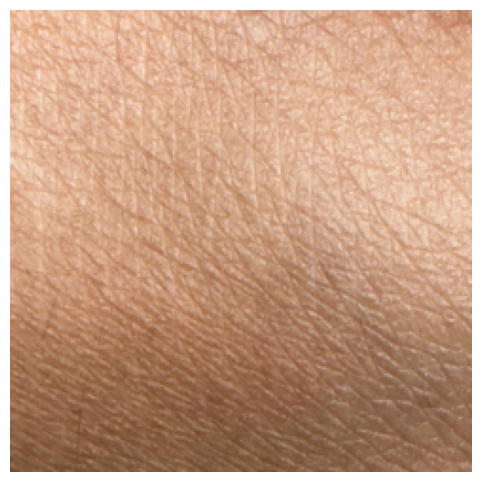

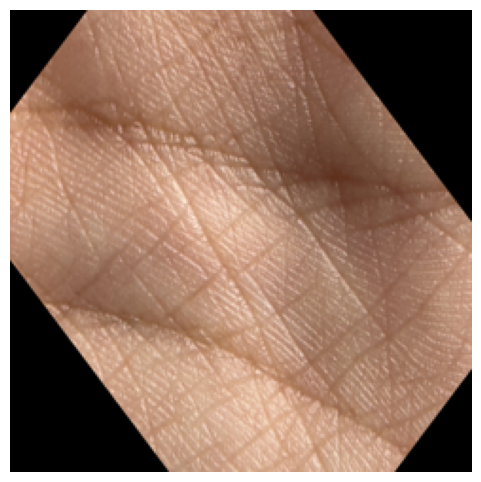

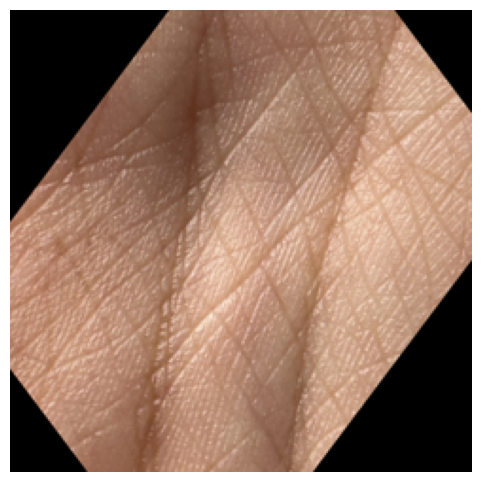

In [23]:
image_folder = "/content/drive/MyDrive/dataset/Augmented/not_infected"

image_list = os.listdir(image_folder)[:3]  # 🔴 only 3 images

for img_name in image_list:
    img_path = os.path.join(image_folder, img_name)
    visualize_rcnn(model, img_path)